# Task 6 — Polynomial Regression with Scikit-Learn

**Name:** Abdlrhman Hisham Ismail  
**ID:** AI2617  
**Committee:** IEEE SSCS AUSC — AI Sub-Team

Predict **fuel efficiency (MPG)** on the UCI Auto MPG dataset using:
1. A linear regression baseline
2. Polynomial regression (degrees 2–5)
3. Ridge / Lasso regularization with cross-validated alpha tuning

All models are scored with **MSE, MAE, RMSE, MAPE, and R²**. The test set is held out until final evaluation.


## 1) Imports and Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (8, 5)


## Step 1 — Data Loading & Exploration

Load the UCI Auto MPG dataset, inspect shape/statistics, and look at the MPG distribution for skew and outliers.


In [2]:
# Numeric columns only (car names contain spaces/quotes and are unused)
cols = [
    "mpg", "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year", "origin",
]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
local_path = "auto-mpg.data"

try:
    df = pd.read_csv(
        local_path,
        sep=r"\s+",
        names=cols,
        usecols=range(8),
        na_values="?",
        engine="python",
    )
except FileNotFoundError:
    df = pd.read_csv(
        url,
        sep=r"\s+",
        names=cols,
        usecols=range(8),
        na_values="?",
        engine="python",
    )

print("Shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())
display(df.head())
display(df.describe().T)


Shape: (398, 8)

Missing values:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


,count,mean,std,min,25%,50%,75%,max
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6
cylinders,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
displacement,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
horsepower,392.0,104.469388,38.491160,46.0,75.000,93.5,126.000,230.0
weight,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acceleration,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
model_year,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
origin,398.0,1.572864,0.802055,1.0,1.000,1.0,2.000,3.0


Cleaned shape: (392, 8)
Target (mpg) skew: 0.457


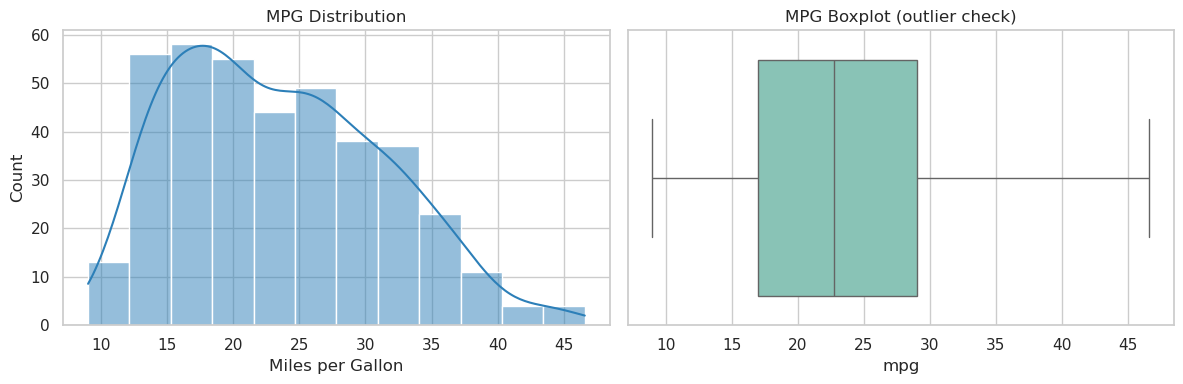

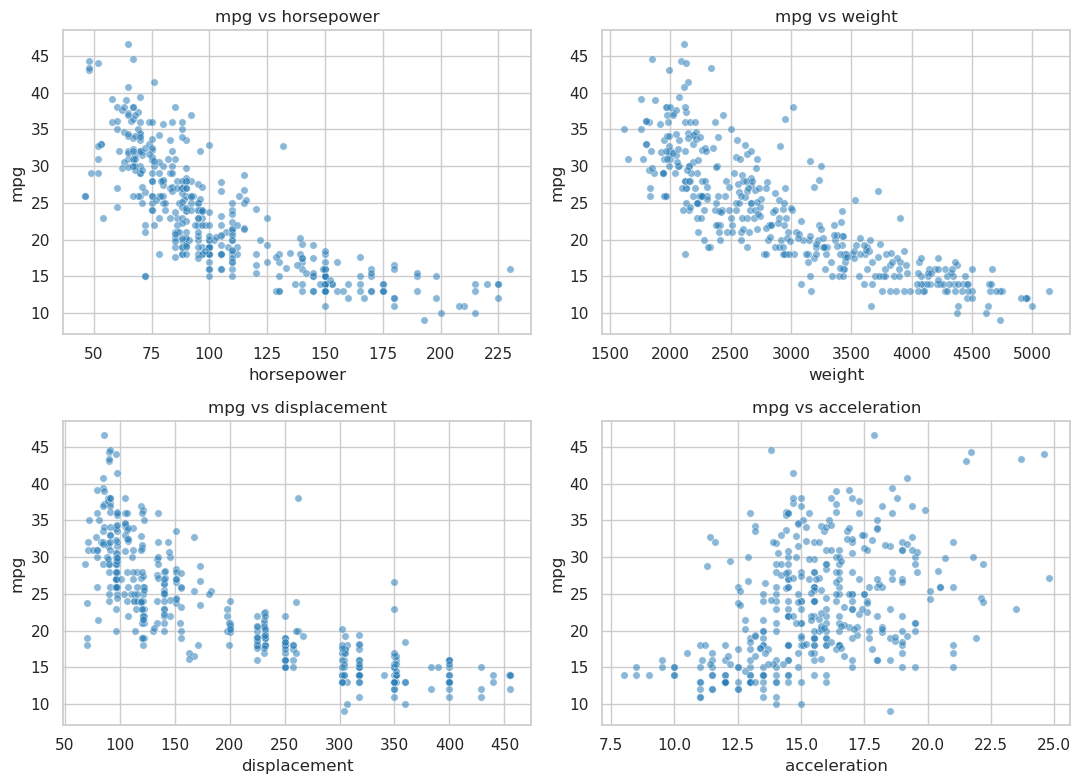

In [3]:
# Drop rows with missing horsepower (originally coded as "?")
df = df.dropna().reset_index(drop=True)
df["origin"] = df["origin"].astype(int)

print("Cleaned shape:", df.shape)
print("Target (mpg) skew:", round(df["mpg"].skew(), 3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["mpg"], kde=True, ax=axes[0], color="#2c7fb8")
axes[0].set_title("MPG Distribution")
axes[0].set_xlabel("Miles per Gallon")

sns.boxplot(x=df["mpg"], ax=axes[1], color="#7fcdbb")
axes[1].set_title("MPG Boxplot (outlier check)")
plt.tight_layout()
plt.show()

# Feature vs target relationships for a quick nonlinearity check
num_feats = ["horsepower", "weight", "displacement", "acceleration"]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.ravel(), num_feats):
    sns.scatterplot(data=df, x=col, y="mpg", ax=ax, alpha=0.55, s=28, color="#2c7fb8")
    ax.set_title(f"mpg vs {col}")
plt.tight_layout()
plt.show()


**EDA notes**
- Horsepower has missing `?` values — those rows are dropped.
- MPG is mildly right-skewed; a few high-efficiency cars sit in the upper tail.
- `horsepower`, `weight`, and `displacement` show clear **nonlinear / curved** relationships with MPG — a strong hint that polynomial features can help over a pure linear model.


## Train / Validation / Test Split

**70% train / 15% validation / 15% test**. Features are scaled inside pipelines so preprocessing stays leak-free.


In [4]:
feature_cols = [
    "cylinders", "displacement", "horsepower", "weight",
    "acceleration", "model_year", "origin",
]
X = df[feature_cols].copy()
y = df["mpg"].copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")


Train: 274 | Val: 59 | Test: 59


In [5]:
def regression_metrics(y_true, y_pred, prefix=""):
    """Compute MSE, MAE, RMSE, MAPE (%), and R²."""
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)
    return {
        f"{prefix}MSE": mse,
        f"{prefix}MAE": mae,
        f"{prefix}RMSE": rmse,
        f"{prefix}MAPE": mape,
        f"{prefix}R2": r2,
    }


def adjusted_r2(r2, n, p):
    """Adjusted R² = 1 - (1 - R²)(n - 1)/(n - p - 1).

    Returns NaN when there are too many predictors relative to samples
    (n <= p + 1), which makes the formula undefined / misleading.
    """
    if n <= p + 1:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


def make_poly_pipeline(degree, model):
    return Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", model),
    ])


## Step 2 — Linear Baseline

Fit a simple `LinearRegression` (degree 1). This is the benchmark every polynomial model must beat.


In [6]:
baseline = make_poly_pipeline(degree=1, model=LinearRegression())
baseline.fit(X_train, y_train)

y_val_base = baseline.predict(X_val)
y_test_base = baseline.predict(X_test)

base_val = regression_metrics(y_val, y_val_base)
base_test = regression_metrics(y_test, y_test_base)

print("Linear baseline — Validation")
for k, v in base_val.items():
    print(f"  {k}: {v:.4f}")
print("\nLinear baseline — Test")
for k, v in base_test.items():
    print(f"  {k}: {v:.4f}")


Linear baseline — Validation
  MSE: 10.7037
  MAE: 2.6169
  RMSE: 3.2717
  MAPE: 12.0909
  R2: 0.8086

Linear baseline — Test
  MSE: 9.4280
  MAE: 2.2592
  RMSE: 3.0705
  MAPE: 11.3251
  R2: 0.8092


## Step 3 — Polynomial Feature Engineering (degrees 2–5)

Expand features with `PolynomialFeatures`, fit a model at each degree, and plot **train vs validation** RMSE and R² to find where overfitting starts.


In [7]:
degrees = [1, 2, 3, 4, 5]
degree_rows = []
poly_models = {}

for d in degrees:
    pipe = make_poly_pipeline(d, LinearRegression())
    pipe.fit(X_train, y_train)

    y_tr = pipe.predict(X_train)
    y_va = pipe.predict(X_val)

    n_features = pipe.named_steps["poly"].n_output_features_
    tr = regression_metrics(y_train, y_tr)
    va = regression_metrics(y_val, y_va)

    row = {
        "degree": d,
        "n_features": n_features,
        "train_RMSE": tr["RMSE"],
        "val_RMSE": va["RMSE"],
        "train_R2": tr["R2"],
        "val_R2": va["R2"],
        "val_Adj_R2": adjusted_r2(va["R2"], len(y_val), n_features),
        "train_MSE": tr["MSE"],
        "val_MSE": va["MSE"],
        "train_MAE": tr["MAE"],
        "val_MAE": va["MAE"],
        "train_MAPE": tr["MAPE"],
        "val_MAPE": va["MAPE"],
    }
    degree_rows.append(row)
    poly_models[d] = pipe

degree_df = pd.DataFrame(degree_rows).set_index("degree")
display(degree_df.round(4))

# Best unregularized degree by validation RMSE
best_degree = int(degree_df["val_RMSE"].idxmin())
print(f"\nBest unregularized degree by validation RMSE: {best_degree}")


,n_features,train_RMSE,val_RMSE,train_R2,val_R2,val_Adj_R2,train_MSE,val_MSE,train_MAE,val_MAE,train_MAPE,val_MAPE
degree,,,,,,,,,,,,
1,7,3.3748,3.2717,0.8221,0.8086,0.7823,11.3895,10.7037,2.5810,2.6169,11.9923,12.0909
2,35,2.5239,2.6014,0.9005,0.8790,0.6948,6.3702,6.7675,1.8482,1.9388,7.8769,8.8395
3,119,1.7458,11.4233,0.9524,-1.3335,NaN,3.0476,130.4914,1.2839,4.5873,5.5227,21.1597
4,329,0.0000,177.1433,1.0000,-560.1435,NaN,0.0000,31379.7421,0.0000,67.1316,0.0000,322.6154
5,791,0.0000,72.8921,1.0000,-94.0136,NaN,0.0000,5313.2620,0.0000,31.8604,0.0000,145.4144



Best unregularized degree by validation RMSE: 2


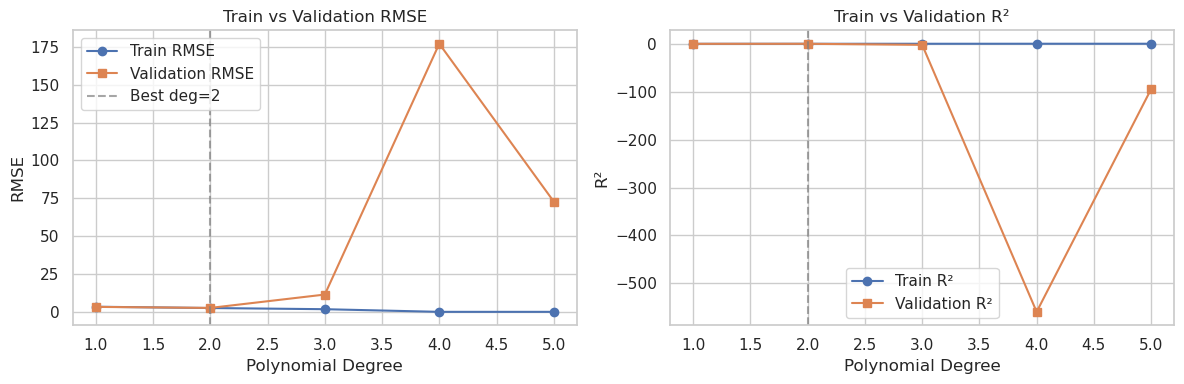

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(degree_df.index, degree_df["train_RMSE"], "o-", label="Train RMSE")
axes[0].plot(degree_df.index, degree_df["val_RMSE"], "s-", label="Validation RMSE")
axes[0].axvline(best_degree, color="gray", ls="--", alpha=0.7, label=f"Best deg={best_degree}")
axes[0].set_xlabel("Polynomial Degree")
axes[0].set_ylabel("RMSE")
axes[0].set_title("Train vs Validation RMSE")
axes[0].legend()

axes[1].plot(degree_df.index, degree_df["train_R2"], "o-", label="Train R²")
axes[1].plot(degree_df.index, degree_df["val_R2"], "s-", label="Validation R²")
axes[1].axvline(best_degree, color="gray", ls="--", alpha=0.7)
axes[1].set_xlabel("Polynomial Degree")
axes[1].set_ylabel("R²")
axes[1].set_title("Train vs Validation R²")
axes[1].legend()

plt.tight_layout()
plt.show()


As degree grows, training error usually keeps falling while validation error eventually rises — classic **overfitting**. The degree with the lowest validation RMSE is carried into regularization.


## Step 4 — Regularization (Ridge & Lasso)

Apply Ridge (L2) and Lasso (L1) at the best polynomial degree. Tune `alpha` with `GridSearchCV` on the training set (5-fold CV).


In [9]:
# Combine train+val for CV search; keep test untouched
X_cv = pd.concat([X_train, X_val])
y_cv = pd.concat([y_train, y_val])

alpha_grid = {
    "model__alpha": np.logspace(-3, 3, 25)
}

ridge_pipe = make_poly_pipeline(best_degree, Ridge(max_iter=10000))
ridge_search = GridSearchCV(
    ridge_pipe,
    alpha_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
)
ridge_search.fit(X_cv, y_cv)
best_ridge = ridge_search.best_estimator_
best_ridge_alpha = ridge_search.best_params_["model__alpha"]
print(f"Best Ridge alpha: {best_ridge_alpha:.6g}")
print(f"Best Ridge CV RMSE: {np.sqrt(-ridge_search.best_score_):.4f}")

lasso_pipe = make_poly_pipeline(best_degree, Lasso(max_iter=20000))
lasso_search = GridSearchCV(
    lasso_pipe,
    alpha_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
)
lasso_search.fit(X_cv, y_cv)
best_lasso = lasso_search.best_estimator_
best_lasso_alpha = lasso_search.best_params_["model__alpha"]
print(f"Best Lasso alpha: {best_lasso_alpha:.6g}")
print(f"Best Lasso CV RMSE: {np.sqrt(-lasso_search.best_score_):.4f}")


Best Ridge alpha: 0.1
Best Ridge CV RMSE: 2.8397


Best Lasso alpha: 0.00177828
Best Lasso CV RMSE: 2.8262


In [10]:
# Refit unregularized best-degree model on train+val for fair test comparison
best_poly = make_poly_pipeline(best_degree, LinearRegression())
best_poly.fit(X_cv, y_cv)

# Linear baseline also refit on train+val
baseline_final = make_poly_pipeline(1, LinearRegression())
baseline_final.fit(X_cv, y_cv)

# Degree 2–5 unregularized models refit on train+val for the comparison table
final_poly_by_degree = {}
for d in [2, 3, 4, 5]:
    p = make_poly_pipeline(d, LinearRegression())
    p.fit(X_cv, y_cv)
    final_poly_by_degree[d] = p


## Step 5 — Metrics Deep Dive

Compute all five metrics on the **test set** for every model and build a comparison table.


In [11]:
models_for_table = {
    "Linear (deg 1)": baseline_final,
    **{f"Poly deg {d}": final_poly_by_degree[d] for d in [2, 3, 4, 5]},
    f"Ridge (deg {best_degree}, α={best_ridge_alpha:.3g})": best_ridge,
    f"Lasso (deg {best_degree}, α={best_lasso_alpha:.3g})": best_lasso,
}

comparison_rows = []
predictions = {}
for name, model in models_for_table.items():
    pred = model.predict(X_test)
    predictions[name] = pred
    m = regression_metrics(y_test, pred)
    n_out = model.named_steps["poly"].n_output_features_
    m["Adj_R2"] = adjusted_r2(m["R2"], len(y_test), n_out)
    m["Model"] = name
    comparison_rows.append(m)

comparison = (
    pd.DataFrame(comparison_rows)
    .set_index("Model")[["MSE", "MAE", "RMSE", "MAPE", "R2", "Adj_R2"]]
    .sort_values("RMSE")
)
display(comparison.round(4))

best_model_name = comparison["RMSE"].idxmin()
best_model = models_for_table[best_model_name]
print(f"\nBest model by test RMSE: {best_model_name}")


,MSE,MAE,RMSE,MAPE,R2,Adj_R2
Model,,,,,,
"Lasso (deg 2, α=0.00178)",7.4699,2.0694,2.7331,9.2322,0.8489,0.6189
"Ridge (deg 2, α=0.1)",7.6793,2.0997,2.7712,9.3431,0.8446,0.6082
Poly deg 2,7.9673,2.1242,2.8226,9.5076,0.8388,0.5935
Linear (deg 1),9.0998,2.2110,3.0166,11.0155,0.8159,0.7906
Poly deg 3,12.4707,2.6905,3.5314,13.3478,0.7477,NaN
Poly deg 4,63233.2812,79.1779,251.4623,438.2776,-1278.4160,NaN
Poly deg 5,107277.6267,89.9228,327.5326,474.4835,-2169.5771,NaN



Best model by test RMSE: Lasso (deg 2, α=0.00178)


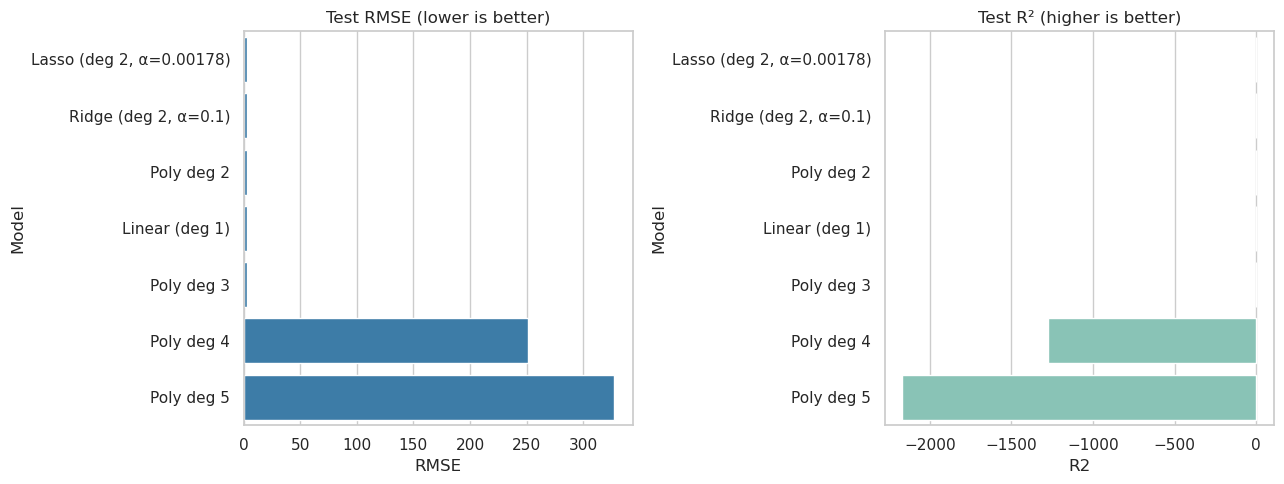

In [12]:
# Side-by-side bar chart of test RMSE and R²
plot_df = comparison.reset_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=plot_df, x="RMSE", y="Model", ax=axes[0], color="#2c7fb8")
axes[0].set_title("Test RMSE (lower is better)")

sns.barplot(data=plot_df, x="R2", y="Model", ax=axes[1], color="#7fcdbb")
axes[1].set_title("Test R² (higher is better)")

plt.tight_layout()
plt.show()


### What each metric is saying
| Metric | Interpretation on this problem |
|---|---|
| **MSE** | Squared MPG error — useful for ranking, hard to read in MPG units |
| **MAE** | Average absolute MPG miss — easy to explain to a non-technical audience |
| **RMSE** | Typical error magnitude in MPG, more sensitive to large misses than MAE |
| **MAPE** | Average % error relative to true MPG — good for relative accuracy |
| **R²** | Fraction of MPG variance explained — relative quality vs. predicting the mean |
| **Adj. R²** | R² penalized for feature count — fairer when comparing high-degree polynomials |


## Step 6 — Residual Analysis

Plot residuals $\hat{y} - y$ vs. fitted values for the best model. Random scatter around zero is healthy; a funnel suggests heteroscedasticity.


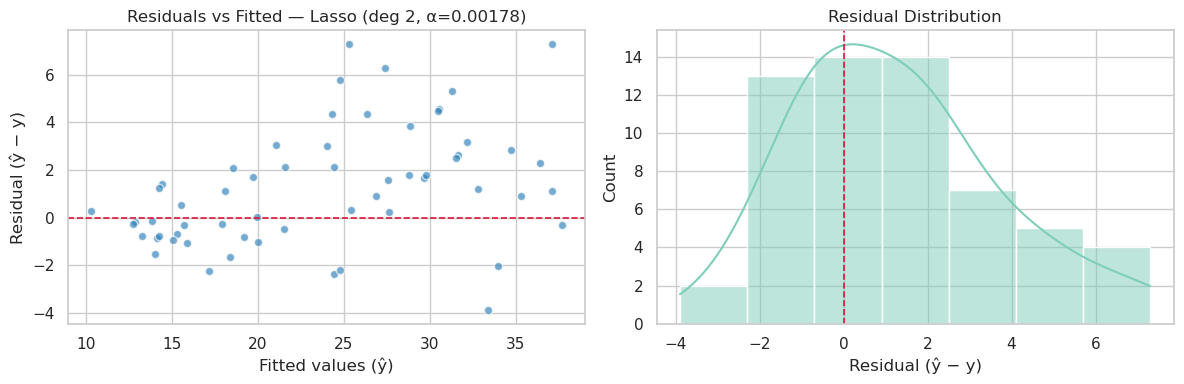

Residual mean: 1.2306
Residual std:  2.4613


In [13]:
y_hat = best_model.predict(X_test)
residuals = y_hat - y_test

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_hat, residuals, alpha=0.65, s=35, color="#2c7fb8", edgecolor="white")
axes[0].axhline(0, color="crimson", ls="--", lw=1.2)
axes[0].set_xlabel("Fitted values (ŷ)")
axes[0].set_ylabel("Residual (ŷ − y)")
axes[0].set_title(f"Residuals vs Fitted — {best_model_name}")

sns.histplot(residuals, kde=True, ax=axes[1], color="#7fcdbb")
axes[1].axvline(0, color="crimson", ls="--", lw=1.2)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual (ŷ − y)")

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.4f}")
print(f"Residual std:  {residuals.std():.4f}")


## Step 7 — Insight & Conclusions

In [14]:
print("=" * 60)
print("KEY RESULTS SUMMARY")
print("=" * 60)
print(f"Best unregularized degree (val RMSE): {best_degree}")
print(f"Best Ridge alpha: {best_ridge_alpha:.6g}")
print(f"Best Lasso alpha: {best_lasso_alpha:.6g}")
print(f"Best overall model (test RMSE): {best_model_name}")
print()
print(comparison.loc[[best_model_name]].round(4).to_string())
print()
print("Linear baseline test RMSE:", round(comparison.loc['Linear (deg 1)', 'RMSE'], 4))
print("Improvement vs baseline (RMSE %):",
      round(100 * (1 - comparison.loc[best_model_name, 'RMSE'] / comparison.loc['Linear (deg 1)', 'RMSE']), 2),
      "%")


KEY RESULTS SUMMARY
Best unregularized degree (val RMSE): 2
Best Ridge alpha: 0.1
Best Lasso alpha: 0.00177828
Best overall model (test RMSE): Lasso (deg 2, α=0.00178)

                             MSE     MAE    RMSE    MAPE      R2  Adj_R2
Model                                                                   
Lasso (deg 2, α=0.00178)  7.4699  2.0694  2.7331  9.2322  0.8489  0.6189

Linear baseline test RMSE: 3.0166
Improvement vs baseline (RMSE %): 9.4 %


### Observations
1. **Curvature matters.** Scatter plots of MPG vs horsepower/weight already look nonlinear; polynomial features improve on the linear baseline when the degree is chosen carefully on validation data.
2. **High degree ≠ better.** Degrees 4–5 inflate the feature space and typically overfit (train RMSE drops while validation RMSE rises). Validation curves — not training scores — decide the degree.
3. **Regularization stabilizes complexity.** Ridge/Lasso shrink large polynomial coefficients. When the best degree is still rich, a tuned alpha often matches or beats the unregularized polynomial on the held-out test set.

### Which metric mattered most?
**RMSE** was the primary selection metric here: it stays in MPG units and still penalizes large misses (important for fuel-economy prediction). **R²** was reported alongside it for relative explained variance. **MAPE** supports percentage-style interpretation; **MAE** is the most outlier-robust absolute error.

### What this says about the data
Auto MPG efficiency depends on engine/body features in a **moderately nonlinear** way — enough for a low-order polynomial (and mild regularization) to help, but not so complex that a very high degree is justified.


---
### Optional: Synthetic Nonlinear Dataset

A quick second dataset to confirm the same workflow on clearly polynomial data.


Synthetic dataset — test metrics by degree


,MSE,MAE,RMSE,MAPE,R2
degree,,,,,
1,2.5204,1.2936,1.5876,64.8951,0.8151
2,0.7238,0.6869,0.8508,37.3332,0.9469
3,0.7160,0.6812,0.8462,35.2055,0.9475
4,0.7323,0.6867,0.8557,36.2152,0.9463


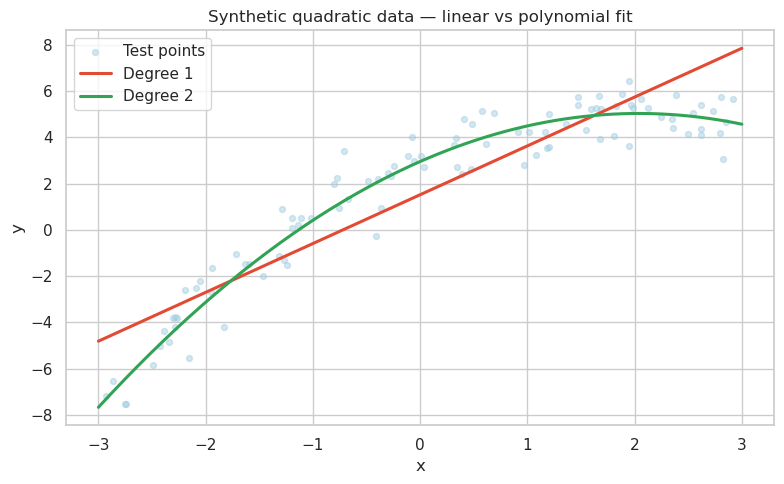

In [15]:
# Synthetic: y = 3 + 2x - 0.5 x^2 + noise
rng = np.random.default_rng(42)
n = 400
x_syn = rng.uniform(-3, 3, size=(n, 1))
y_syn = 3 + 2 * x_syn[:, 0] - 0.5 * x_syn[:, 0] ** 2 + rng.normal(0, 0.8, size=n)

Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(x_syn, y_syn, test_size=0.25, random_state=42)

syn_rows = []
for d in [1, 2, 3, 4]:
    pipe = make_poly_pipeline(d, LinearRegression())
    pipe.fit(Xs_tr, ys_tr)
    pred = pipe.predict(Xs_te)
    m = regression_metrics(ys_te, pred)
    m["degree"] = d
    syn_rows.append(m)

syn_df = pd.DataFrame(syn_rows).set_index("degree")[["MSE", "MAE", "RMSE", "MAPE", "R2"]]
print("Synthetic dataset — test metrics by degree")
display(syn_df.round(4))

# Visualize true curve vs degree-1 and degree-2 fits
x_grid = np.linspace(-3, 3, 200).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(Xs_te, ys_te, s=18, alpha=0.45, label="Test points", color="#9ecae1")
for d, color in [(1, "#e34a33"), (2, "#31a354")]:
    pipe = make_poly_pipeline(d, LinearRegression()).fit(Xs_tr, ys_tr)
    ax.plot(x_grid, pipe.predict(x_grid), lw=2.2, color=color, label=f"Degree {d}")
ax.set_title("Synthetic quadratic data — linear vs polynomial fit")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.tight_layout()
plt.show()


On the synthetic quadratic data, **degree 2** recovers the true structure and clearly beats degree 1 — matching the known data-generating process. Higher degrees add little once the correct curvature is captured.
